# Introduction to NumPy and Matplotlib
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
NumPy is the backbone of scientific computing in Python. Every time you store an EMG time-series, compute joint kinematics, filter a force signal, or run a statistical analysis, NumPy arrays are doing the heavy lifting under the hood. Matplotlib, its companion library, lets you visualize everything from raw signals to publication-quality figures.

This notebook walks you through every essential NumPy (and basic Matplotlib) operation, using examples drawn from movement neuroscience research wherever possible.

**Prerequisites:** Python Basics (variables, loops, functions).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---

## Table of Contents

1. [Why NumPy? — Speed Comparison](#1)
2. [Creating and Operating on Arrays](#2)
3. [Introduction to Matplotlib](#3)
4. [Multidimensional Arrays](#4)
5. [Basic Indexing and Slicing](#5)
6. [Boolean Indexing](#6)
7. [Fancy Indexing](#7)
8. [Universal Functions (ufuncs)](#8)
9. [Mathematical and Statistical Methods](#9)
10. [Handling NaN Values](#10)
11. [Pseudorandom Number Generation](#11)
12. [Array-Oriented Programming with Meshgrid](#12)
13. [Conditional Logic with `np.where`](#13)
14. [Linear Algebra](#14)
15. [Advanced NumPy — Reshaping, Concatenation, Broadcasting](#15)
16. [Exercises](#16)
17. [Summary & Further Reading](#17)

In [1]:
# ---- Setup: import the two libraries we'll use throughout ----
# NumPy  → numerical arrays and math operations
# Matplotlib → plotting and visualization

import numpy as np
import matplotlib.pyplot as plt

---
## 1. Why NumPy? — Speed Comparison <a id='1'></a>

NumPy is **dramatically faster** than plain Python for numerical work. Its core is written in C, so array operations avoid the overhead of Python's interpreted loops.

In movement neuroscience, you regularly work with arrays of millions of samples (e.g., 30 minutes of EMG at 2000 Hz = 3.6 million samples). Speed matters.

In [2]:
# ---- Speed comparison: NumPy array vs Python list ----
# We'll multiply 1 million numbers by 2 using each approach.
# %timeit is a Jupyter "magic" command that runs the code many times and reports the average time.

my_arr = np.arange(1_000_000)            # NumPy array of 0..999,999
my_list = list(range(1_000_000))          # Plain Python list of the same

%timeit my_arr2 = my_arr * 2              # NumPy: vectorized C operation
%timeit my_list2 = [x * 2 for x in my_list]  # Python: interpreted loop

1.24 ms ± 138 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
55.4 ms ± 1.24 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


You should see that NumPy is roughly **50–100× faster**. This is why we never use plain Python loops for numerical computation in scientific code — we use NumPy's vectorized operations instead.

---
## 2. Creating and Operating on Arrays <a id='2'></a>

The core object in NumPy is the **`ndarray`** (N-dimensional array). It allows fast mathematical operations on entire arrays at once, without explicit `for` loops.

### 2.1 Creating a 1-D Array

In [3]:
# ---- Create a simple 1-D array from a list ----

x = np.array([1, 3, 5, 6])
print(x)

[1 3 5 6]


### 2.2 Element-wise Operations

Arithmetic on NumPy arrays works **element-wise** — each operation is applied to every element simultaneously, with no loop required.

In [4]:
# ---- Element-wise math: squaring, trig functions, reciprocals ----

x = np.array([1, 3, 5, 6])

y = x ** 2                    # Square each element
print(f"x²  = {y}")

z = np.exp(np.sin(x))        # exp(sin(x)) applied element-wise
print(f"e^sin(x) = {z}")

w = 1 / x                    # Reciprocal — no special syntax needed (unlike MATLAB's 1./x)
print(f"1/x = {w}")

x²  = [ 1  9 25 36]
e^sin(x) = [2.31977682 1.15156284 0.383305   0.75622563]
1/x = [1.         0.33333333 0.2        0.16666667]


### 2.3 Generating Evenly Spaced Arrays

Two essential functions for creating regularly spaced data:

| Function | Syntax | Key behavior |
|---|---|---|
| `np.linspace` | `linspace(start, stop, num)` | **Includes** `stop`; you specify the **number of points** |
| `np.arange` | `arange(start, stop, step)` | **Excludes** `stop`; you specify the **step size** |

Use `linspace` when you know how many points you want. Use `arange` when you know the step size.

In [5]:
# ---- linspace vs arange — notice the difference! ----

x_lin = np.linspace(0, 1, 101)  # 101 points from 0 to 1 INCLUSIVE
x_rng = np.arange(0, 1, 0.01)   # Points from 0 up to (but NOT including) 1

print(f"linspace: {len(x_lin)} points, last = {x_lin[-1]}")  # 101 points, ends at 1.0
print(f"arange:   {len(x_rng)} points, last = {x_rng[-1]}")  # 100 points, ends at 0.99

linspace: 101 points, last = 1.0
arange:   100 points, last = 0.99


In [6]:
# ---- Apply a math operation to evenly spaced data ----
# This pattern is the basis of all signal generation and analysis.

x = np.linspace(0, 1, 101)
w = np.sin(np.pi * x)   # A half-period sine wave
print(f"First 5 values of sin(π·x): {w[:5]}")

First 5 values of sin(π·x): [0.         0.03141076 0.06279052 0.09410831 0.12533323]


### 2.4 Defining and Using Functions with Arrays

You can define your own functions and pass NumPy arrays as arguments. The function operates element-wise automatically.

In [7]:
# ---- Define a custom function and apply it to an array ----
# Example: a simple quadratic f(x) = a·x² + b

def f(x, a, b):
    """Evaluate the quadratic a*x^2 + b element-wise."""
    return a * x**2 + b

x = np.linspace(0, 1, 101)
y = f(x, 2, 1)  # a=2, b=1 → y = 2x² + 1

print(f"f(0)={y[0]}, f(0.5)={y[50]}, f(1)={y[-1]}")

f(0)=1.0, f(0.5)=1.5, f(1)=3.0


---
## 3. Introduction to Matplotlib <a id='3'></a>

Matplotlib is Python's most widely used plotting library. We imported it at the top as `plt`. Let's make some basic plots.

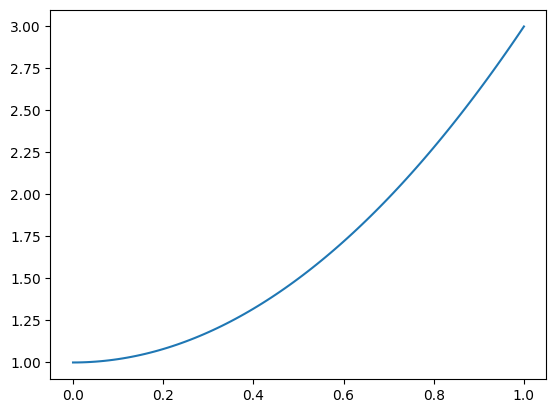

In [8]:
# ---- The simplest possible plot ----

plt.plot(x, y)
plt.show()

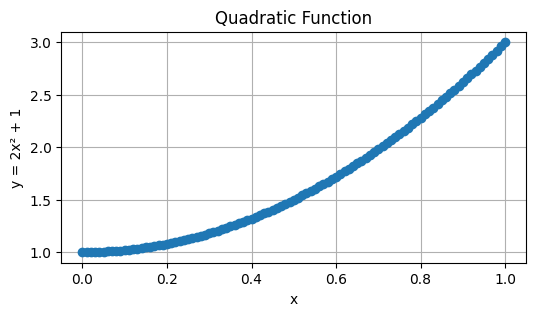

In [9]:
# ---- A more polished plot with labels, title, and grid ----

plt.figure(figsize=(6, 3))   # Set figure size (width, height) in inches
plt.plot(x, y, 'o--')        # 'o--' means circle markers with dashed line
plt.xlabel('x')
plt.ylabel('y = 2x² + 1')
plt.title('Quadratic Function')
plt.grid(True)               # Add a background grid
plt.show()

In [10]:
# ---- Accessing particular elements of an array ----
# Indexing starts at 0. Negative indices count from the end.

print(f"Last element of y: {y[-1]}")
print(f"First element of y: {y[0]}")

Last element of y: 3.0
First element of y: 1.0


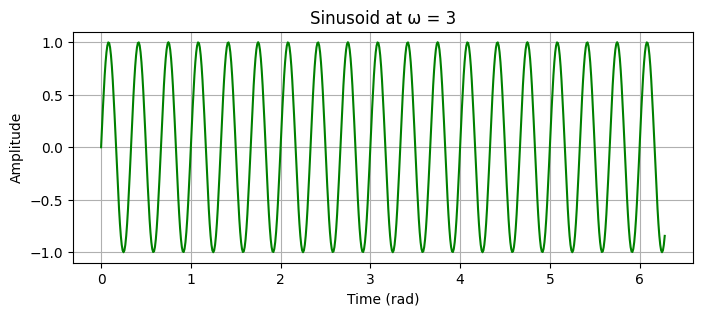

In [11]:
# ---- Plotting a sinusoidal signal ----
# Movement neuroscience analogy: a sinusoid can model rhythmic movements
# (e.g., oscillatory wrist flexion–extension at a given frequency).

x = np.arange(0, 2 * np.pi, 0.01)  # Time axis from 0 to 2π
omega = 3                            # Frequency (cycles per 2π)
y = np.sin(2 * np.pi * omega * x)   # Sinusoidal signal

plt.figure(figsize=(8, 3))
plt.plot(x, y, 'g')                 # 'g' = green line
plt.xlabel('Time (rad)')
plt.ylabel('Amplitude')
plt.title(f'Sinusoid at ω = {omega}')
plt.grid(True)
plt.show()

---
## 4. Multidimensional Arrays <a id='4'></a>

Real-world data is often multidimensional. In movement neuroscience:
- A **2-D array** might store multiple trials (rows) × time samples (columns).
- A **3-D array** might store participants × trials × time samples.

### 4.1 Creating and Operating on 2-D Arrays

In [12]:
# ---- Create a 2-D array (matrix) ----

data = np.array([[1.5, -0.1, 3],
                 [0.2, -3, 6.5]])
print("data:")
print(data)

# ---- Element-wise arithmetic works on matrices too ----
data2 = data + data          # Add corresponding elements
print("\ndata + data:")
print(data2)

inv_data = 1 / data          # Element-wise reciprocal
print("\n1 / data:")
print(inv_data)

data:
[[ 1.5 -0.1  3. ]
 [ 0.2 -3.   6.5]]

data + data:
[[ 3.  -0.2  6. ]
 [ 0.4 -6.  13. ]]

1 / data:
[[  0.66666667 -10.           0.33333333]
 [  5.          -0.33333333   0.15384615]]


### 4.2 Array Properties: Shape, Dimensions, and Data Type

In [13]:
# ---- Inspecting an array's properties ----

print(f"Shape: {data.shape}")   # (2, 3) → 2 rows, 3 columns
print(f"Ndim:  {data.ndim}")    # 2 → two-dimensional
print(f"Dtype: {data.dtype}")   # float64 → 64-bit floating point

Shape: (2, 3)
Ndim:  2
Dtype: float64


In [14]:
# ---- Changing data types with .astype() ----
# Sometimes you need to convert floats to integers (e.g., for indexing).

arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
print(f"Original: {arr} (dtype: {arr.dtype})")

arr_int = arr.astype(np.int32)  # Truncates decimals (does NOT round)
print(f"As int32: {arr_int} (dtype: {arr_int.dtype})")

Original: [ 3.7 -1.2 -2.6  0.5 12.9 10.1] (dtype: float64)
As int32: [ 3 -1 -2  0 12 10] (dtype: int32)


---
## 5. Basic Indexing and Slicing <a id='5'></a>

**Important:** Python uses **0-based indexing** (unlike MATLAB which starts at 1).

### 5.1 Slicing 1-D Arrays

A critical difference from many other languages: **NumPy slices are views, not copies**. Modifying a slice modifies the original array.

In [15]:
# ---- Slicing and assignment in a 1-D array ----

arr = np.arange(10)       # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(f"Original: {arr}")

arr[5:8] = 12             # Set elements at indices 5, 6, 7 to 12
print(f"After arr[5:8]=12: {arr}")

Original: [0 1 2 3 4 5 6 7 8 9]
After arr[5:8]=12: [ 0  1  2  3  4 12 12 12  8  9]


In [16]:
# ---- CRITICAL: Slices are VIEWS, not copies! ----
# Modifying the slice modifies the original array.

arr_slice = arr[5:8]
print(f"Slice: {arr_slice}")

arr_slice[:] = 667       # Change every element in the slice
print(f"Original arr after modifying slice: {arr}")
# Notice: arr[5], arr[6], arr[7] are now 667!

Slice: [12 12 12]
Original arr after modifying slice: [  0   1   2   3   4 667 667 667   8   9]


In [17]:
# ---- To avoid this, use .copy() to get an independent copy ----

arr_slice2 = arr[5:8].copy()   # Explicit copy
print(f"Copied slice: {arr_slice2}")

arr_slice2[:] = 397            # Modify the copy
print(f"Original arr (unchanged): {arr}")

Copied slice: [667 667 667]
Original arr (unchanged): [  0   1   2   3   4 667 667 667   8   9]


**Why this matters:** If you load raw EMG data and take a slice for analysis, modifying that slice will corrupt your original data unless you explicitly copy it first.

### 5.2 Indexing 2-D Arrays

Think of axis 0 as the **rows** and axis 1 as the **columns**.

In [18]:
# ---- 2-D array indexing ----

arr2d = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])
print("arr2d:")
print(arr2d)

arr2d:
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [19]:
# ---- Accessing individual elements and slices ----

print(f"arr2d[1][2] = {arr2d[1][2]}")   # Row 1, Column 2 → 6
print(f"arr2d[:2]:")
print(arr2d[:2])                          # First 2 rows

arr2d[1][2] = 6
arr2d[:2]:
[[1 2 3]
 [4 5 6]]


In [20]:
# ---- Negative indexing ----
# -1 refers to the LAST element along that axis.

print(f"Last row, first col: arr2d[-1, 0] = {arr2d[-1, 0]}")  # 7
print(f"All rows, last col:  arr2d[:, -1] = {arr2d[:, -1]}")  # [3, 6, 9]

Last row, first col: arr2d[-1, 0] = 7
All rows, last col:  arr2d[:, -1] = [3 6 9]


In [21]:
# ---- Transpose: swap rows and columns ----

print("Transpose:")
print(arr2d.T)

Transpose:
[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [22]:
# ---- Combined row and column slicing ----
# arr2d[:2, -1]  → first 2 rows, last column
# arr2d[:2, 1:]  → first 2 rows, columns from index 1 onward

print(f"arr2d[:2, -1]  = {arr2d[:2, -1]}")   # [3, 6]
print(f"arr2d[:2, 1:] =\n{arr2d[:2, 1:]}")  # [[2,3],[5,6]]

arr2d[:2, -1]  = [3 6]
arr2d[:2, 1:] =
[[2 3]
 [5 6]]


---
## 6. Boolean Indexing <a id='6'></a>

Boolean indexing is one of NumPy's most powerful features. It lets you **select elements based on conditions** — invaluable for filtering trials, removing outliers, or extracting epochs from a signal.

### 6.1 Selecting Rows by Condition

In [23]:
# ---- Select rows in 'data' based on values in 'names' ----
# Imagine 'names' are participant IDs and 'data' are their measurements.

names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

print(f"names: {names}")
print(f"data shape: {data.shape}")

names: ['Bob' 'Joe' 'Will' 'Bob' 'Will' 'Joe' 'Joe']
data shape: (7, 2)


In [24]:
# ---- Boolean mask: which rows belong to "Bob"? ----

mask_bob = (names == "Bob")
print(f"Bob mask:  {mask_bob}")        # [True, False, False, True, ...]
print(f"Bob's data:\n{data[mask_bob]}")  # Rows 0 and 3

Bob mask:  [ True False False  True False False False]
Bob's data:
[[4 7]
 [0 0]]


In [25]:
# ---- Invert a Boolean mask with ~ ("not") ----
# Select all rows where name is NOT Bob, and only the last column.

not_bob_last_col = data[~mask_bob, -1]
print(f"Non-Bob, last column: {not_bob_last_col}")

not_bob_from_col1 = data[~mask_bob, 1:]
print(f"Non-Bob, columns 1+:\n{not_bob_from_col1}")

Non-Bob, last column: [ 2  6  2 -4  4]
Non-Bob, columns 1+:
[[ 2]
 [ 6]
 [ 2]
 [-4]
 [ 4]]


**Note:** The `~` operator inverts a Boolean array. Use `&` for element-wise AND, `|` for element-wise OR. **Do not** use the Python keywords `and` / `or` with arrays — they don't work element-wise.

In [26]:
# ---- Using Boolean indexing to modify data ----
# Common use case: clamp negative values to zero.

data[data < 0] = 0   # Set ALL negative elements to 0
print("After clamping negatives to 0:")
print(data)

After clamping negatives to 0:
[[4 7]
 [0 2]
 [0 6]
 [0 0]
 [1 2]
 [0 0]
 [3 4]]


### 6.2 Boolean Indexing for Plotting Subsets

A very common pattern in neuroscience: plot a full signal, then highlight a specific region based on a condition.

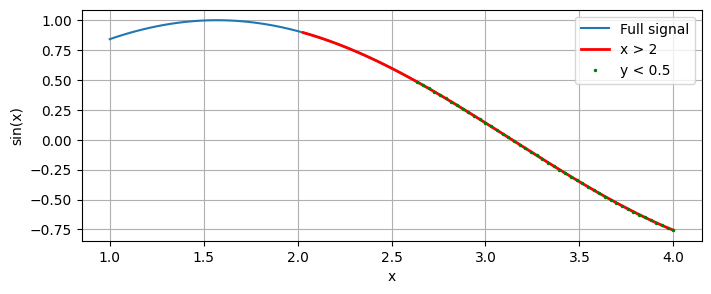

In [27]:
# ---- Boolean indexing to select and plot subsets ----

x = np.linspace(1, 4, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))
plt.plot(x, y, label='Full signal')                     # Full signal in blue
plt.plot(x[x > 2], y[x > 2], 'r', linewidth=2,
         label='x > 2')                                  # Highlight region where x > 2
plt.plot(x[y < 0.5], y[y < 0.5], 'g.', markersize=3,
         label='y < 0.5')                                # Highlight where y < 0.5
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.legend()
plt.grid(True)
plt.show()

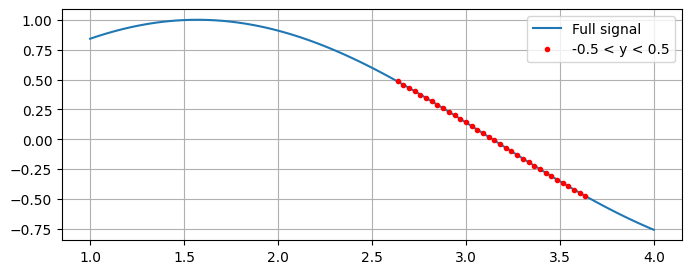

In [28]:
# ---- Combining conditions with & (AND) and | (OR) ----
# IMPORTANT: each condition must be in parentheses when combining!

plt.figure(figsize=(8, 3))
plt.plot(x, y, label='Full signal')

# Select where y is between -0.5 and 0.5
mask = (y > -0.5) & (y < 0.5)
plt.plot(x[mask], y[mask], 'ro', markersize=3, label='-0.5 < y < 0.5')

plt.legend()
plt.grid(True)
plt.show()

---
## 7. Fancy Indexing <a id='7'></a>

**Fancy indexing** uses **integer arrays** as indices to select specific rows or elements in a custom order. Unlike slicing, fancy indexing **always copies** the data.

This is useful for selecting specific trials, shuffling data, or reordering channels.

In [29]:
# ---- Fancy indexing: select specific rows ----

arr = np.zeros((8, 4))         # 8×4 matrix of zeros
for i in range(8):
    arr[i] = i                 # Fill each row with its index number

print("Original:")
print(arr)

# Select rows 4, 3, 0, 6 — in that specific order
print("\nFancy indexed [4, 3, 0, 6]:")
print(arr[[4, 3, 0, 6]])

# Same result using negative indices:
print("\nSame with negative indices [-4, -5, -8, -2]:")
print(arr[[-4, -5, -8, -2]])

Original:
[[0. 0. 0. 0.]
 [1. 1. 1. 1.]
 [2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]
 [5. 5. 5. 5.]
 [6. 6. 6. 6.]
 [7. 7. 7. 7.]]

Fancy indexed [4, 3, 0, 6]:
[[4. 4. 4. 4.]
 [3. 3. 3. 3.]
 [0. 0. 0. 0.]
 [6. 6. 6. 6.]]

Same with negative indices [-4, -5, -8, -2]:
[[4. 4. 4. 4.]
 [3. 3. 3. 3.]
 [0. 0. 0. 0.]
 [6. 6. 6. 6.]]


In [30]:
# ---- Fancy indexing with reshape ----

arr = np.arange(32).reshape((8, 4))  # Reshape 0..31 into an 8×4 matrix
print(arr)

# Select individual elements: (1,0), (5,3), (7,1), (2,2)
print(f"\nElements [1,5,7,2], [0,3,1,2] = {arr[[1, 5, 7, 2], [0, 3, 1, 2]]}")

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]

Elements [1,5,7,2], [0,3,1,2] = [ 4 23 29 10]


In [31]:
# ---- Fancy indexing always copies data ----
# You can also use it to SET values.

print("Before:")
print(arr)

arr[[1, 5, 7, 2], [0, 3, 1, 2]] = 0  # Zero out those specific elements
print("\nAfter setting selected elements to 0:")
print(arr)

Before:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]

After setting selected elements to 0:
[[ 0  1  2  3]
 [ 0  5  6  7]
 [ 8  9  0 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22  0]
 [24 25 26 27]
 [28  0 30 31]]


In [32]:
# ---- Challenge from the original notebook: ----
# Create a 4×4 matrix with 5 on the diagonals and -1 on all off-diagonals.

matrix = 5 * np.eye(4) - np.ones((4, 4))  # eye(4) is the 4×4 identity matrix
# 5*I gives 5 on diagonal, 0 elsewhere; subtracting ones gives -1 off-diagonal, 4 on diagonal.
# Correction: this gives 4 on diagonal. For 5 on diagonal:
matrix = 6 * np.eye(4) - np.ones((4, 4))  # 6-1=5 on diagonal, 0-1=-1 off-diagonal
print(matrix)

[[ 5. -1. -1. -1.]
 [-1.  5. -1. -1.]
 [-1. -1.  5. -1.]
 [-1. -1. -1.  5.]]


---
## 8. Universal Functions (ufuncs) <a id='8'></a>

Universal functions (ufuncs) perform fast, element-wise operations on arrays. These include `np.sqrt`, `np.exp`, `np.sin`, `np.maximum`, and many more.

In [33]:
# ---- Unary ufuncs: operate on one array ----

arr = np.arange(0, 10, 3)
print(f"arr = {arr}")
print(f"sqrt(arr) = {np.sqrt(arr)}")

arr = [0 3 6 9]
sqrt(arr) = [0.         1.73205081 2.44948974 3.        ]


In [34]:
# ---- Binary ufuncs: operate on two arrays ----
# np.maximum returns the element-wise maximum of two arrays.

x = np.random.randn(8)
y = np.random.randn(8)
z = np.maximum(x, y)   # Element-wise max

print(f"x = {np.round(x, 2)}")
print(f"y = {np.round(y, 2)}")
print(f"max(x,y) = {np.round(z, 2)}")

x = [ 0.53 -0.76 -1.3  -0.08  0.72 -0.32 -0.27  1.14]
y = [ 0.78 -0.75 -2.33 -0.49  0.48 -0.49 -1.55  0.77]
max(x,y) = [ 0.78 -0.75 -1.3  -0.08  0.72 -0.32 -0.27  1.14]


In [35]:
# ---- np.modf: separate fractional and integer parts ----
# Python allows multiple return values — a pattern you'll see often.

arr = np.random.randn(7) * 5
print(f"arr = {np.round(arr, 2)}")

remainder, whole_int = np.modf(arr)  # Returns TWO arrays
print(f"Fractional parts: {np.round(remainder, 2)}")
print(f"Integer parts:    {whole_int}")

arr = [-6.33 -3.79 -5.28  0.71 -6.15 -2.79 -2.8 ]
Fractional parts: [-0.33 -0.79 -0.28  0.71 -0.15 -0.79 -0.8 ]
Integer parts:    [-6. -3. -5.  0. -6. -2. -2.]


---
## 9. Mathematical and Statistical Methods <a id='9'></a>

NumPy arrays have built-in methods for computing statistics — essential for summarizing experimental data.

In [36]:
# ---- Mean, computed globally and along specific axes ----

arr = np.random.randn(6, 4)  # 6 rows × 4 columns (e.g., 6 trials × 4 measures)

print(f"Global mean:        {np.mean(arr):.4f}")
print(f"Column means (axis=0): {np.mean(arr, axis=0).round(4)}")  # Mean across rows → 4 values
print(f"Row means (axis=1):    {np.mean(arr, axis=1).round(4)}")  # Mean across columns → 6 values

Global mean:        0.1057
Column means (axis=0): [ 0.3235  0.194  -0.8025  0.708 ]
Row means (axis=1):    [-0.1547  0.9343 -0.0664 -0.2189 -0.4251  0.5652]


**Axis convention:** `axis=0` collapses **rows** (operates down columns). `axis=1` collapses **columns** (operates across rows). Think of it as: the axis you specify is the one that *disappears*.

In [37]:
# ---- Cumulative sum: running total ----
# Useful for computing cumulative displacement from velocity data.

arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
print(f"Array:    {arr}")
print(f"Cum. sum: {arr.cumsum()}")  # Running total: [0, 1, 3, 6, 10, 15, 21, 28]

Array:    [0 1 2 3 4 5 6 7]
Cum. sum: [ 0  1  3  6 10 15 21 28]


---
## 10. Handling NaN Values <a id='10'></a>

Real experimental data **always** has missing values — sensor dropouts, failed trials, marker occlusions, or aborted recordings. NumPy represents missing data as `np.nan` ("Not a Number").

**The critical gotcha:** Standard NumPy functions like `np.mean` will return `nan` if **any** element is `nan`. This silently ruins your analysis if you don't handle it.

NumPy provides a family of **NaN-safe functions** that skip `nan` values automatically:

| Standard function | NaN-safe version | What it does |
|---|---|---|
| `np.mean()` | `np.nanmean()` | Mean, ignoring NaN |
| `np.std()` | `np.nanstd()` | Standard deviation, ignoring NaN |
| `np.sum()` | `np.nansum()` | Sum, ignoring NaN |
| `np.max()` | `np.nanmax()` | Maximum, ignoring NaN |
| `np.min()` | `np.nanmin()` | Minimum, ignoring NaN |
| `np.median()` | `np.nanmedian()` | Median, ignoring NaN |

In [ ]:
# ---- The NaN gotcha: standard functions silently fail ----

# Imagine these are reaction times with two missing trials:
rts = np.array([0.31, 0.29, np.nan, 0.34, 0.28, np.nan, 0.33])

print(f"np.mean(rts) = {np.mean(rts)}")     # nan! Your entire result is ruined.
print(f"np.std(rts)  = {np.std(rts)}")      # nan!
print(f"np.max(rts)  = {np.max(rts)}")      # nan!

# ---- NaN-safe versions: skip NaN automatically ----
print(f"\nnp.nanmean(rts) = {np.nanmean(rts):.4f}")   # Correct mean of valid values
print(f"np.nanstd(rts)  = {np.nanstd(rts):.4f}")
print(f"np.nanmax(rts)  = {np.nanmax(rts)}")

In [ ]:
# ---- Detecting NaN values ----

print(f"Which elements are NaN? {np.isnan(rts)}")   # Boolean mask
print(f"How many NaN?           {np.isnan(rts).sum()}")
print(f"How many valid?         {np.count_nonzero(~np.isnan(rts))}")

# Select only the valid (non-NaN) values:
valid_rts = rts[~np.isnan(rts)]
print(f"\nValid RTs: {valid_rts}")
print(f"Mean of valid: {valid_rts.mean():.4f}")

In [ ]:
# ---- Replacing NaN values ----

# Replace NaN with a specific value (e.g., 0):
replaced = np.nan_to_num(rts, nan=0.0)
print(f"nan_to_num (nan→0): {replaced}")

# Replace NaN with the mean of valid values (common imputation):
imputed = rts.copy()
imputed[np.isnan(imputed)] = np.nanmean(imputed)
print(f"Imputed with mean:  {np.round(imputed, 3)}")

In [ ]:
# ---- NaN-safe functions work with axis parameter too ----
# This is critical when computing per-trial or per-channel stats on 2-D data.

# Simulate 4 trials × 5 sensors, with some dropouts:
data_2d = np.array([[1.2, 0.8, np.nan, 1.1, 0.9],
                    [1.3, np.nan, 0.7, 1.0, 0.8],
                    [1.1, 0.9, 0.6, np.nan, 1.0],
                    [1.4, 0.7, 0.8, 1.2, np.nan]])

print(f"Per-trial means (axis=1):  {np.nanmean(data_2d, axis=1).round(3)}")
print(f"Per-sensor means (axis=0): {np.nanmean(data_2d, axis=0).round(3)}")
print(f"\nTotal NaN count: {np.isnan(data_2d).sum()}")

**Best practice:** Always use `np.nanmean` / `np.nanstd` / etc. when working with experimental data, unless you are **certain** there are no missing values. The extra `nan` prefix costs nothing in performance and protects you from silent errors.

---
## 11. Pseudorandom Number Generation <a id='11'></a>

Random numbers are essential for simulations, bootstrapping, and generating synthetic data for testing your analysis pipeline.

In [38]:
# ---- Two ways to generate random arrays ----

arr1 = np.random.randn(6, 4)           # Standard normal (mean=0, std=1)
arr2 = np.random.normal(size=(6, 4))   # Same distribution, slightly different syntax

print("np.random.randn(6,4):")
print(arr1.round(2))
print("\nnp.random.normal(size=(6,4)):")
print(arr2.round(2))

np.random.randn(6,4):
[[ 0.84  1.06  0.86 -0.27]
 [-0.42  1.34  0.54 -0.6 ]
 [ 0.12 -0.23 -1.13  1.26]
 [-2.27 -0.96  1.29 -0.83]
 [-1.49 -1.31 -0.94  0.97]
 [-0.21 -0.87 -0.82  2.51]]

np.random.normal(size=(6,4)):
[[ 1.3  -0.11  1.96 -0.56]
 [ 0.48 -0.91  0.17 -1.8 ]
 [-0.47  0.28  0.16 -1.32]
 [ 0.03  0.88  2.17  1.49]
 [ 0.9   0.86  1.06  1.42]
 [-1.04  0.94  1.38  2.12]]


In [39]:
# ---- Setting a seed for reproducibility ----
# A seed ensures you get the SAME random numbers every time.
# Critical for reproducible research!

# Modern approach (recommended): use a Generator object
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((3, 4))
print("Reproducible random data:")
print(data.round(3))

Reproducible random data:
[[-1.424  1.264 -0.871 -0.259]
 [-0.075 -0.741 -1.368  0.649]
 [ 0.361 -1.953  2.347  0.968]]


In [40]:
# ---- Important: assignment vs. copy for nested structures ----
# Note: plain Python lists don't share memory the way NumPy slices do.

a = [[2, 3, 4], [3, 4, 5]]
b = np.array(a).T      # Convert to NumPy and transpose
b[1] = 7               # Modify b
print(f"b:\n{b}")
print(f"a (unchanged): {a}")  # a is a plain list — not linked to b

b:
[[2 3]
 [7 7]
 [4 5]]
a (unchanged): [[2, 3, 4], [3, 4, 5]]


---
## 12. Array-Oriented Programming with Meshgrid <a id='12'></a>

NumPy lets you express computations over grids of values without any loops. The key function is `np.meshgrid`, which creates 2-D coordinate arrays from 1-D axes.

**Neuroscience analogy:** Think of evaluating a receptive field model over a grid of spatial locations, or computing a 2-D joint torque surface.

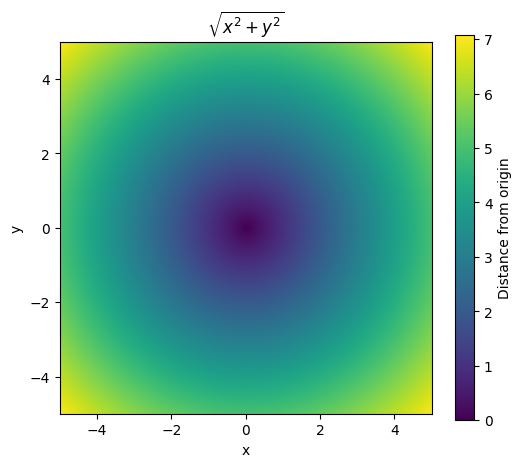

In [41]:
# ---- Evaluate sqrt(x² + y²) over a 2-D grid ----

points = np.arange(-5, 5, 0.01)          # 1000 points from -5 to 5
xs, ys = np.meshgrid(points, points)      # Create 2-D coordinate grids

z = np.sqrt(xs**2 + ys**2)                # Evaluate the function

plt.figure(figsize=(6, 5))
plt.imshow(z, cmap='viridis', extent=[-5, 5, -5, 5])
plt.colorbar(label='Distance from origin')
plt.title(r'$\sqrt{x^2 + y^2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

---
## 13. Conditional Logic with `np.where` <a id='13'></a>

`np.where` is the vectorized version of Python's `x if condition else y`. It's far faster than a list comprehension for large arrays.

In [42]:
# ---- np.where: vectorized conditional selection ----

xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

# Slow way (Python loop via list comprehension):
result_slow = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]
print(f"List comprehension: {result_slow}")

# Fast way (vectorized):
result_fast = np.where(cond, xarr, yarr)
print(f"np.where:           {result_fast}")

List comprehension: [np.float64(1.1), np.float64(2.2), np.float64(1.3), np.float64(1.4), np.float64(2.5)]
np.where:           [1.1 2.2 1.3 1.4 2.5]


In [43]:
# ---- np.where with scalars: replace values conditionally ----
# Example: label all positive values as +2 and negative as -2.

rng = np.random.default_rng(seed=42)
arr = rng.standard_normal((4, 4))
print("Original:")
print(arr.round(2))

labeled = np.where(arr > 0, 2, -2)  # +2 if positive, -2 if negative
print("\nLabeled (+2/-2):")
print(labeled)

Original:
[[ 0.3  -1.04  0.75  0.94]
 [-1.95 -1.3   0.13 -0.32]
 [-0.02 -0.85  0.88  0.78]
 [ 0.07  1.13  0.47 -0.86]]

Labeled (+2/-2):
[[ 2 -2  2  2]
 [-2 -2  2 -2]
 [-2 -2  2  2]
 [ 2  2  2 -2]]


In [44]:
# ---- np.where: replace only positive values, keep the rest ----
# Neuroscience use case: clamp EMG rectification by replacing only positive values.

clamped = np.where(arr > 0, 2, arr)  # Set positives to 2; leave negatives unchanged
print(clamped.round(2))

[[ 2.   -1.04  2.    2.  ]
 [-1.95 -1.3   2.   -0.32]
 [-0.02 -0.85  2.    2.  ]
 [ 2.    2.    2.   -0.86]]


---
## 14. Linear Algebra <a id='14'></a>

Linear algebra operations — matrix multiplication, inverses, decompositions — are fundamental to biomechanical modeling, PCA on neural data, and solving systems of equations.

### 13.1 Matrix Multiplication

In [45]:
# ---- Matrix multiplication (dot product) ----
# Note: the * operator does element-wise multiplication.
# For matrix multiplication, use @ or np.dot().

x = np.array([[1., 2., 3.],
              [4., 5., 6.]])       # Shape: (2, 3)
y = np.array([[6., 23.],
              [-1, 7],
              [8, 9]])              # Shape: (3, 2)

print(f"x shape: {x.shape}, y shape: {y.shape}")
print(f"\nx @ y =\n{x @ y}")               # (2,3) @ (3,2) → (2,2)
print(f"\nnp.dot(x, y) =\n{np.dot(x, y)}") # Equivalent

x shape: (2, 3), y shape: (3, 2)

x @ y =
[[ 28.  64.]
 [ 67. 181.]]

np.dot(x, y) =
[[ 28.  64.]
 [ 67. 181.]]


In [46]:
# ---- Matrix × vector product ----

result = x @ np.ones(3)  # (2,3) @ (3,) → (2,)
print(f"x @ [1,1,1] = {result}")  # Row sums of x

x @ [1,1,1] = [ 6. 15.]


### 13.2 Inverse and Decompositions

In [47]:
# ---- Matrix inverse and verification ----

from numpy.linalg import inv, qr

rng = np.random.default_rng(seed=12345)
X = rng.standard_normal((5, 5))  # Random 5×5 matrix

mat = X.T @ X                     # X'X is always square and (usually) invertible
mat_inv = inv(mat)

# Verify: mat @ inv(mat) should be ≈ identity matrix
identity_approx = mat @ mat_inv
print("mat @ inv(mat) ≈ I:")
print(identity_approx.round(6))

mat @ inv(mat) ≈ I:
[[ 1. -0.  0.  0.  0.]
 [ 0.  1. -0. -0. -0.]
 [-0. -0.  1.  0.  0.]
 [ 0.  0. -0.  1. -0.]
 [ 0. -0. -0. -0.  1.]]


---
## 15. Advanced NumPy — Reshaping, Concatenation, Broadcasting <a id='15'></a>

This section covers more advanced array manipulation techniques that become essential when you're working with real experimental data.

### 14.1 Reshaping Arrays

In [48]:
# ---- Reshape: change the shape without copying data ----

arr = np.arange(8)
print(f"Original (1-D): {arr}")
print(f"Reshaped (4×2):\n{arr.reshape((4, 2))}")

# Use -1 to let NumPy infer one dimension:
arr15 = np.arange(15)
print(f"\n15 elements reshaped to (5, -1):\n{arr15.reshape((5, -1))}")

Original (1-D): [0 1 2 3 4 5 6 7]
Reshaped (4×2):
[[0 1]
 [2 3]
 [4 5]
 [6 7]]

15 elements reshaped to (5, -1):
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [49]:
# ---- Reshape to match another array's shape ----

other_arr = np.ones((3, 5))
print(f"Target shape: {other_arr.shape}")
print(f"Reshaped:\n{arr15.reshape(other_arr.shape)}")

Target shape: (3, 5)
Reshaped:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]


In [50]:
# ---- Flatten: convert any array back to 1-D ----
# .ravel() returns a VIEW (fast, no copy)
# .flatten() returns a COPY (safe, always new memory)

arr2d = np.arange(15).reshape((5, 3))
print(f"2-D array:\n{arr2d}")
print(f"\nRaveled: {arr2d.ravel()}")
print(f"Flattened: {arr2d.flatten()}")

2-D array:
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]

Raveled: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


### 14.2 Concatenating and Splitting Arrays

Common in research: combine data from multiple trials or split a recording into segments.

In [51]:
# ---- Concatenate: join arrays along an axis ----

arr1 = np.array([[1, 2, 3], [4, 5, 6]])
arr2 = np.array([[7, 8, 9], [10, 11, 12]])

# Vertical stack (axis=0): add more rows
print(f"vstack:\n{np.vstack((arr1, arr2))}")

# Horizontal stack (axis=1): add more columns
print(f"\nhstack:\n{np.hstack((arr1, arr2))}")

# np.concatenate is the general version:
print(f"\nconcatenate (axis=0):\n{np.concatenate([arr1, arr2], axis=0)}")

vstack:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

hstack:
[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]

concatenate (axis=0):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [52]:
# ---- Split: slice an array into multiple pieces ----
# np.split(arr, [i, j]) splits at indices i and j.

rng = np.random.default_rng(seed=42)
arr = rng.standard_normal((5, 2))

first, second, third = np.split(arr, [1, 3])  # Split into rows [0], [1:3], [3:]
print(f"First (row 0):\n{first}")
print(f"\nSecond (rows 1-2):\n{second}")
print(f"\nThird (rows 3-4):\n{third}")

First (row 0):
[[ 0.30471708 -1.03998411]]

Second (rows 1-2):
[[ 0.7504512   0.94056472]
 [-1.95103519 -1.30217951]]

Third (rows 3-4):
[[ 0.1278404  -0.31624259]
 [-0.01680116 -0.85304393]]


### 14.3 Repeating Elements: `repeat` and `tile`

In [53]:
# ---- repeat: repeat each element ----

arr = np.arange(3)            # [0, 1, 2]
print(f"arr.repeat(3) = {arr.repeat(3)}")  # [0,0,0, 1,1,1, 2,2,2]

arr.repeat(3) = [0 0 0 1 1 1 2 2 2]


In [54]:
# ---- repeat along a specific axis ----

rng = np.random.default_rng(seed=0)
arr = rng.standard_normal((2, 2))
print(f"Original:\n{arr.round(2)}")
print(f"\nRepeat 2× along axis 0 (duplicate rows):\n{arr.repeat(2, axis=0).round(2)}")

Original:
[[ 0.13 -0.13]
 [ 0.64  0.1 ]]

Repeat 2× along axis 0 (duplicate rows):
[[ 0.13 -0.13]
 [ 0.13 -0.13]
 [ 0.64  0.1 ]
 [ 0.64  0.1 ]]


In [55]:
# ---- tile: stack copies of the entire array ----

print(f"Original:\n{arr.round(2)}")
print(f"\nnp.tile(arr, 2):\n{np.tile(arr, 2).round(2)}")

Original:
[[ 0.13 -0.13]
 [ 0.64  0.1 ]]

np.tile(arr, 2):
[[ 0.13 -0.13  0.13 -0.13]
 [ 0.64  0.1   0.64  0.1 ]]


### 14.4 Broadcasting

**Broadcasting** governs how operations work between arrays of **different shapes**. It's one of NumPy's most powerful (and sometimes confusing) features.

**The broadcasting rule:** Two arrays are compatible if, for each trailing dimension, the sizes are either **equal** or one of them is **1**.

In [56]:
# ---- Simplest broadcasting: scalar × array ----
# The scalar 4 is "broadcast" to match the array's shape.

arr = np.arange(5)
print(f"arr * 4 = {arr * 4}")  # [0, 4, 8, 12, 16]

arr * 4 = [ 0  4  8 12 16]


In [57]:
# ---- Demeaning columns: subtract the column mean from each row ----
# This is a very common preprocessing step (e.g., baseline correction).

rng = np.random.default_rng(seed=12345)
arr = rng.standard_normal((4, 3))

col_means = arr.mean(axis=0)   # Shape: (3,) — one mean per column
print(f"Column means: {col_means.round(3)}")

demeaned = arr - col_means     # (4,3) - (3,) → broadcasts along axis 0
print(f"Demeaned column means (≈ 0): {demeaned.mean(axis=0).round(10)}")

Column means: [-1.251  1.046 -0.07 ]
Demeaned column means (≈ 0): [0. 0. 0.]


In [58]:
# ---- Demeaning ROWS requires reshaping ----
# Row means have shape (4,), but we need (4,1) for broadcasting across columns.

row_means = arr.mean(axis=1)                # Shape: (4,)
print(f"Row means shape: {row_means.shape}") # (4,) — can't broadcast against (4,3)

# Reshape to (4,1) so broadcasting works:
demeaned_rows = arr - row_means.reshape((4, 1))  # (4,3) - (4,1) → OK!
print(f"Demeaned row means (≈ 0): {demeaned_rows.mean(axis=1).round(10)}")

Row means shape: (4,)
Demeaned row means (≈ 0): [-0. -0.  0. -0.]


### 14.5 `np.newaxis` — Adding Dimensions for Broadcasting

In [59]:
# ---- np.newaxis inserts a new dimension of size 1 ----
# This is a cleaner alternative to .reshape() for broadcasting.

arr = np.zeros((4, 4))
arr_3d = arr[:, np.newaxis, :]   # Insert a new axis in the middle
print(f"Original shape: {arr.shape}")     # (4, 4)
print(f"3-D shape:      {arr_3d.shape}")  # (4, 1, 4)

Original shape: (4, 4)
3-D shape:      (4, 1, 4)


In [60]:
# ---- Convert a 1-D array to a column vector or row vector ----

rng = np.random.default_rng(seed=12345)
arr_1d = rng.standard_normal(3)

print(f"Column vector shape: {arr_1d[:, np.newaxis].shape}")  # (3, 1)
print(f"Row vector shape:    {arr_1d[np.newaxis, :].shape}")  # (1, 3)

Column vector shape: (3, 1)
Row vector shape:    (1, 3)


In [61]:
# ---- Demeaning a 3-D array along axis 2 ----
# Use np.newaxis to align the means for broadcasting.

arr = rng.standard_normal((3, 4, 5))
depth_means = arr.mean(axis=2)           # Shape: (3, 4)
print(f"arr shape: {arr.shape}, depth_means shape: {depth_means.shape}")

demeaned = arr - depth_means[:, :, np.newaxis]  # (3,4,5) - (3,4,1) → OK!
print(f"Demeaned axis-2 means (≈ 0):\n{demeaned.mean(axis=2).round(10)}")

arr shape: (3, 4, 5), depth_means shape: (3, 4)
Demeaned axis-2 means (≈ 0):
[[-0. -0. -0. -0.]
 [ 0. -0.  0.  0.]
 [ 0. -0.  0. -0.]]


In [62]:
# ---- Generalized demeaning function ----
# This works for any axis of any N-dimensional array.

def demean_axis(arr, axis=0):
    """
    Subtract the mean along the specified axis, using broadcasting.
    Works for arrays of any number of dimensions.
    """
    means = arr.mean(axis)
    # Build an indexer that inserts np.newaxis at the correct position
    indexer = [slice(None)] * arr.ndim
    indexer[axis] = np.newaxis
    return arr - means[tuple(indexer)]

# Test it:
test = rng.standard_normal((3, 4, 5))
result = demean_axis(test, axis=1)
print(f"Demeaned axis-1 means (≈ 0):\n{result.mean(axis=1).round(10)}")

Demeaned axis-1 means (≈ 0):
[[ 0. -0.  0. -0. -0.]
 [ 0.  0.  0.  0. -0.]
 [ 0.  0.  0.  0.  0.]]


### 14.6 Setting Array Values by Broadcasting

In [63]:
# ---- Broadcast a scalar to fill an entire array ----

arr = np.zeros((4, 3))
arr[:] = 5           # Scalar 5 is broadcast to fill all elements
print(arr)

[[5. 5. 5.]
 [5. 5. 5.]
 [5. 5. 5.]
 [5. 5. 5.]]


In [64]:
# ---- Broadcast a column vector into every column ----

col = np.array([1.28, -0.42, 0.44, 1.6])
arr[:] = col[:, np.newaxis]   # (4,1) broadcasts to fill (4,3)
print(arr)

[[ 1.28  1.28  1.28]
 [-0.42 -0.42 -0.42]
 [ 0.44  0.44  0.44]
 [ 1.6   1.6   1.6 ]]


In [65]:
# ---- Set specific rows using broadcasting ----

arr[:2] = [[-1.37], [0.509]]  # Set first 2 rows; (2,1) broadcasts to (2,3)
print(arr)

[[-1.37  -1.37  -1.37 ]
 [ 0.509  0.509  0.509]
 [ 0.44   0.44   0.44 ]
 [ 1.6    1.6    1.6  ]]


---
## 16. Exercises <a id='16'></a>

Test your understanding by completing these exercises. Each one uses the concepts from this tutorial.

---

### Exercise 1: Simulate and Plot an EMG Burst

Generate a synthetic EMG signal:
1. Create a time vector from 0 to 2 seconds at 1000 Hz using `np.arange`.
2. Create a Gaussian activation envelope centered at 1.0 s with a width of 0.2 s:  
   `envelope = np.exp(-0.5 * ((t - 1.0) / 0.2)**2)`
3. Multiply the envelope by random noise (`np.random.randn`) to simulate EMG.
4. Plot the raw EMG and the envelope on the same figure.

In [ ]:
# ---- YOUR CODE HERE ----

# Step 1: time vector
# t = ...

# Step 2: Gaussian envelope
# envelope = ...

# Step 3: synthetic EMG
# emg = ...

# Step 4: plot
# plt.figure(figsize=(10, 3))
# plt.plot(...)
# plt.show()

### Exercise 2: Boolean Indexing for Outlier Removal

Given an array of reaction times, remove any value more than 2 standard deviations from the mean:
1. Compute the mean and std of the array.
2. Create a Boolean mask for values within 2 SDs.
3. Apply the mask to get the cleaned data.
4. Print how many outliers were removed.

In [ ]:
# ---- YOUR CODE HERE ----

rng = np.random.default_rng(seed=42)
reaction_times = rng.normal(loc=0.350, scale=0.05, size=100)  # 100 trials, mean=350ms
reaction_times[10] = 0.9   # Inject an outlier
reaction_times[50] = 0.05  # Inject another outlier

# TODO: compute mean and std
# TODO: create Boolean mask for |value - mean| < 2*std
# TODO: apply mask and count removed trials

### Exercise 3: Baseline Correction with Broadcasting

You have a 2-D array where each row is a trial (10 trials × 500 time samples). The first 100 samples of each trial are the baseline period. Subtract each trial's baseline mean from the entire trial (i.e., baseline correction).

Hint: compute the mean of columns 0–99 for each row (`axis=1`), then use broadcasting.

In [ ]:
# ---- YOUR CODE HERE ----

rng = np.random.default_rng(seed=0)
data = rng.standard_normal((10, 500)) + np.linspace(0, 5, 10)[:, np.newaxis]
# Each trial has a different DC offset (simulating baseline drift)

# TODO: compute baseline mean for each trial (first 100 samples)
# baseline_means = ...

# TODO: subtract baseline (use broadcasting with reshape or np.newaxis)
# corrected = ...

# Verify: the mean of the first 100 samples of each corrected trial should ≈ 0
# print(corrected[:, :100].mean(axis=1).round(6))

### Exercise 4: Matrix Operations (Challenge)

A common task in biomechanics is solving for unknown forces given known positions and a stiffness matrix.

Given: `K @ x = F` (stiffness × displacement = force)  
Solve for `x` given `K` and `F`.

1. Create a random symmetric positive-definite matrix `K` (hint: `K = A.T @ A + np.eye(n)`).
2. Create a known force vector `F`.
3. Solve for `x` using `np.linalg.solve(K, F)` (more stable than `inv(K) @ F`).
4. Verify by computing `K @ x` and checking it matches `F`.

In [ ]:
# ---- YOUR CODE HERE ----

# Step 1: create a 4×4 symmetric positive-definite matrix K
# A = rng.standard_normal((4, 4))
# K = ...

# Step 2: create force vector
# F = np.array([10, 20, 30, 40])

# Step 3: solve for x
# x = np.linalg.solve(K, F)

# Step 4: verify
# print(f"K @ x = {(K @ x).round(6)}")
# print(f"F     = {F}")

---
## 17. Summary & Further Reading <a id='17'></a>

### What You Learned

| Concept | What it does | Example |
|---|---|---|
| **`np.array()`** | Create an array from a list | `np.array([1, 2, 3])` |
| **Element-wise ops** | Math on every element at once | `arr ** 2`, `np.sin(arr)` |
| **`linspace` / `arange`** | Generate evenly spaced data | `np.linspace(0, 1, 101)` |
| **`plt.plot()`** | Basic line plot | `plt.plot(t, signal)` |
| **`.shape`, `.ndim`, `.dtype`** | Inspect array properties | `arr.shape` → `(6, 4)` |
| **Slicing (views!)** | Select subsets; shares memory | `arr[5:8]` |
| **`.copy()`** | Independent copy of data | `arr[5:8].copy()` |
| **Boolean indexing** | Select by condition | `data[data > 0]` |
| **Fancy indexing** | Select by integer array (copies) | `arr[[4, 3, 0, 6]]` |
| **ufuncs** | Fast element-wise functions | `np.sqrt`, `np.maximum` |
| **`.mean()`, `.std()`, `.cumsum()`** | Statistical methods with axis control | `arr.mean(axis=0)` |
| **`rng = default_rng(seed)`** | Reproducible random numbers | `rng.standard_normal((3,4))` |
| **`np.meshgrid`** | 2-D coordinate grids | Evaluate functions over surfaces |
| **`np.nanmean` etc.** | NaN-safe statistics | `np.nanmean([1, nan, 3])` → `2.0` |
| **`np.isnan`** | Detect missing values | `np.isnan(arr).sum()` |
| **`np.where`** | Vectorized conditional logic | `np.where(arr > 0, 1, -1)` |
| **`@` / `np.dot`** | Matrix multiplication | `x @ y` |
| **`inv`, `solve`** | Linear algebra | `np.linalg.solve(K, F)` |
| **`.reshape()`, `.ravel()`** | Change array shape | `arr.reshape((5, -1))` |
| **`vstack`, `hstack`, `split`** | Combine / split arrays | `np.vstack((a, b))` |
| **Broadcasting** | Operations on mismatched shapes | `(4,3) - (3,)` → auto-expands |
| **`np.newaxis`** | Add dimension for broadcasting | `arr[:, np.newaxis]` |

### Further Reading

- [NumPy Quickstart Tutorial](https://numpy.org/doc/stable/user/quickstart.html) — official getting-started guide
- [NumPy for MATLAB Users](https://numpy.org/doc/stable/user/numpy-for-matlab-users.html) — essential if you're coming from MATLAB
- [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/index.html) — from basic to advanced plotting
- [Broadcasting in Depth](https://numpy.org/doc/stable/user/basics.broadcasting.html) — the official broadcasting rules
- [MNE-Python](https://mne.tools/) — uses NumPy arrays everywhere for EEG/MEG data

### What's Next?

With NumPy and Matplotlib mastered, you're ready to tackle:
- **Pandas** — for structured tabular data (participant metadata, trial tables)
- **SciPy** — for signal processing (filtering, spectral analysis), optimization, and statistics
- **Object-Oriented Programming** — for organizing your analysis code into reusable classes

---

*Happy coding, and may your arrays be well-shaped and your broadcasts compatible!*